# Notebook 3 — Machine Learning for Hourly Electricity Consumption Forecasting
## BigDataCompany · E-REDES Portugal

---

## Overview

This notebook builds and evaluates regression models for hourly electricity consumption
across Portuguese municipalities, using as input the dataset produced in
Notebook 2. The trained pipeline is saved and loaded directly by Notebook 4 (Streaming)
to run inference on simulated live smart-meter data.

**The primary goal is not to maximise model accuracy.** This is a proof-of-concept
demonstrating Spark MLlib's ability to train, evaluate, and serialise a forecasting
pipeline at scale. The model is a functional tool — accurate enough to produce
meaningful predictions in the streaming simulation, but secondary to the Spark
engineering demonstration.

---

## Models

| Model | Framework | Role |
|---|---|---|
| Linear Regression | Spark MLlib | Interpretable baseline |
| Gradient Boosted Trees (GBT) | Spark MLlib | Primary model — saved for streaming |

**Why Linear Regression?** It establishes a minimum performance bar and provides
interpretable coefficients. If GBT does not beat it substantially, the features are
not capturing meaningful non-linear patterns.

**Why GBT?** It handles non-linearities and feature interactions (e.g. `hour_of_day ×
is_holiday`) that are common in energy demand data, and is natively distributed in
Spark MLlib — training parallelises across partitions without any code changes.

---

## Spark ML Pipeline

All preprocessing and model stages are encapsulated in a single `Pipeline` object.
This is the correct Spark-native approach for two reasons:

1. **Big-data safety** — the pipeline applies transformations lazily and in a
   distributed manner. No data is collected to the driver at any stage.
2. **Streaming compatibility** — a fitted `PipelineModel` can be called with
   `.transform()` directly on a streaming DataFrame in Notebook 4. The pipeline
   is serialised to disk with `.save()` and reloaded without retraining.

---

## Train / Validation / Stream Split

Because this is time-series data, splits are **date-based**, not random.
A random split would allow future observations into the training set, constituting
data leakage.

| Split | Period | Purpose |
|---|---|---|
| Train | Up to last week − 1 | Model fitting |
| Validation | Last week before stream cutoff | Hyperparameter evaluation |
| Stream (held out) | Final week | Notebook 4 streaming simulation |

The stream portion is never seen by any model fitting or validation step.

---

## Evaluation Metrics

We report two levels of evaluation — overall and per-municipality — because this
dataset is not a single time series. It contains one independent time series per
municipality (~278 series). An overall RMSE that looks acceptable can mask a model
that performs well on high-consumption urban municipalities (Lisboa, Porto) while
failing completely on low-consumption rural ones. Per-municipality metrics expose this.

### Overall metrics (aggregate)

| Metric | Why it matters here |
|---|---|
| **RMSE** | Primary metric. Penalises large errors heavily — important for grid planning where missed peak demand is costly. |
| **MAE** | Average absolute error in kWh. More interpretable for communicating accuracy to a non-technical audience. |
| **R²** | Proportion of variance explained across the full dataset. Useful for comparing models. |


> Overall metrics are dominated by high-consumption municipalities simply because
> their absolute errors are larger. A model with good overall RMSE may still be
> useless for rural municipalities where consumption is low and variance is small.

### Per-municipality metrics (the meaningful evaluation)

For each municipality we compute **MAPE** (Mean Absolute Percentage Error) rather
than RMSE or MAE. Percentage error is the only metric that puts all municipalities
on a comparable scale regardless of their consumption magnitude — a 10 kWh error
means something very different in Lisboa vs. Alcoutim.

From the per-municipality MAPEs we then report:

| Statistic | What it tells us |
|---|---|
| **Median MAPE** | Typical model performance across all series — more robust than mean. |
| **90th percentile MAPE** | How bad the worst cases are. High P90 means the model is unreliable for a significant minority of municipalities. |
| **Best / worst 10 municipalities** | Identifies where the model works and where it breaks down — useful for diagnosing whether failures are geographic, seasonal, or data-quality related (estimated vs. metered). |

---

## 1. Environment Setup

In [1]:
from pathlib import Path
import sys

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Running in Google Colab")

    PROJECT_ROOT = Path(
        "/content/drive/MyDrive/e_redes_v2/e_redes"
    )

    sys.path.append(str(PROJECT_ROOT))

except ImportError:
    print("Not running in Google Colab")

    PROJECT_ROOT = Path.cwd().parent
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.append(str(PROJECT_ROOT))


Mounted at /content/drive
Running in Google Colab


In [2]:
# Install Java 17 — required for Spark
!sudo apt-get update -qq
!sudo apt-get install -y openjdk-17-jdk-headless -qq
!java -version

# Tell PySpark where Java lives
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
openjdk version "17.0.19" 2026-04-21
OpenJDK Runtime Environment (build 17.0.19+10-1-22.04.2-Ubuntu)
OpenJDK 64-Bit Server VM (build 17.0.19+10-1-22.04.2-Ubuntu, mixed mode, sharing)


In [3]:
import warnings
import itertools
warnings.filterwarnings('ignore')

import pyspark
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType
from pyspark.ml.regression import GBTRegressor


# MLlib — Pipeline and feature engineering
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler,
    StringIndexer, OneHotEncoder
)

# MLlib — Models
from pyspark.ml.regression import (
    LinearRegression,
    RandomForestRegressor,
    GBTRegressor
)

# MLlib — Evaluation and tuning
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
sys.path.append('/content/drive/MyDrive/e_redes')


import pandas as pd
from utils.feature_eng import (
    TemporalFeatureTransformer,
    HolidayFlagTransformer,
    LagFeatureTransformer,
    NullLagDropTransformer
)

from utils.evaluation import (
    evaluate_model,
    evaluate_by_municipality,
    compare_models
)


# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"]    = 100

print(f"PySpark version: {pyspark.__version__}")
print(f"Python:          {sys.version.split('|')[0].strip()}")

PySpark version: 4.0.2
Python:          3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [4]:
spark = (
    SparkSession.builder
        .master("local[*]")
        .appName("bda_eredes_modelling")
        .config("spark.executor.memory", "8g")
        .config("spark.driver.memory", "8g")
        .config("spark.sql.shuffle.partitions", "16")
        .config("spark.sql.adaptive.enabled", "true")
        .getOrCreate()
)


spark

In [5]:
from config import (
    DATA_MODEL,
    TARGET_COL,
    MODEL_INPUT_PARQUET,
    MODEL_DIR

)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = str(MODEL_DIR)
print(MODEL_DIR)

TARGET_COL = "total_active_energy_kwh"

/content/drive/MyDrive/e_redes_v2/e_redes/models


---
## 2. Load & Inspect Model Input Data

In [6]:
df = spark.read.parquet(MODEL_INPUT_PARQUET)
df.createOrReplaceTempView("eredes")

print(f"Total rows:    {df.count():,}")
print(f"Total columns: {len(df.columns)}")
print("\nSchema:")
df.printSchema()

print("\nSample:")
df.show(3, truncate=False)

Total rows:    2,228,170
Total columns: 4

Schema:
root
 |-- municipality: string (nullable = true)
 |-- datetime: timestamp (nullable = true)
 |-- total_active_energy_kwh: double (nullable = true)
 |-- year_month: string (nullable = true)


Sample:
+------------------+-------------------+-----------------------+----------+
|municipality      |datetime           |total_active_energy_kwh|year_month|
+------------------+-------------------+-----------------------+----------+
|condeixa-a-nova   |2023-05-03 16:00:00|5913.101846668479      |2023-05   |
|oliveira de frades|2023-05-20 14:00:00|3169.825822066332      |2023-05   |
|arouca            |2023-05-20 14:00:00|4670.486609147821      |2023-05   |
+------------------+-------------------+-----------------------+----------+
only showing top 3 rows


---
## 3. Train / Test Split

For time series data, a **temporal split** is mandatory — we cannot use
random splitting. Random splitting would allow the model to train on
future data (e.g. February) and predict past data (e.g. January),
which constitutes **data leakage** and produces optimistically biased metrics.

We use the last 7 days of the series as the test set, everything before as training.

In [7]:
max_date = df.agg(F.max("datetime")).first()[0]
min_date = df.agg(F.min("datetime")).first()[0]

# Build splits from the end backwards — stream is last, then test, then train
# All cutoffs land on midnight to avoid partial-day boundary rows
cutoff_stream  = max_date - pd.Timedelta(days=7)   # stream: last 7 days
cutoff_test    = cutoff_stream - pd.Timedelta(days=30)  # test: 30 days before stream

# ── Splits ────────────────────────────────────────────────────────────────────
train_df = df.filter(F.col("datetime") < cutoff_test)

test_df = df.filter(
    (F.col("datetime") >= cutoff_test) &
    (F.col("datetime") < cutoff_stream)
)

stream_source_df = df.filter(F.col("datetime") >= cutoff_stream)

# ── Verify no overlap and no gap ──────────────────────────────────────────────
train_max  = train_df.agg(F.max("datetime")).first()[0]
test_min   = test_df.agg(F.min("datetime")).first()[0]
test_max   = test_df.agg(F.max("datetime")).first()[0]
stream_min = stream_source_df.agg(F.min("datetime")).first()[0]

assert train_max  < test_min,   "OVERLAP: train bleeds into test"
assert test_max   < stream_min, "OVERLAP: test bleeds into stream"

# ── Counts ────────────────────────────────────────────────────────────────────
train_count  = train_df.count()
test_count   = test_df.count()
stream_count = stream_source_df.count()
total        = train_count + test_count + stream_count

print(f"Full dataset:  {total:,} rows  |  {min_date}  →  {max_date}")
print(f"─" * 60)
print(f"Train:         {train_count:,} rows  ({train_count/total*100:.1f}%)")
print(f"               {min_date}  →  {train_max}")
print(f"Test:          {test_count:,} rows  ({test_count/total*100:.1f}%)")
print(f"               {test_min}  →  {test_max}")
print(f"Stream:        {stream_count:,} rows  ({stream_count/total*100:.1f}%)")
print(f"               {stream_min}  →  {max_date}")
print(f"─" * 60)
print(f"Overlap check: train∩test={0}  test∩stream={0}  ✓")

# Cap max_date to training period for all CV functions in this notebook
max_date = cutoff_test

Full dataset:  2,228,170 rows  |  2022-11-01 00:00:00  →  2023-09-30 22:00:00
────────────────────────────────────────────────────────────
Train:         1,981,028 rows  (88.9%)
               2022-11-01 00:00:00  →  2023-08-24 21:00:00
Test:          200,160 rows  (9.0%)
               2023-08-24 22:00:00  →  2023-09-23 21:00:00
Stream:        46,982 rows  (2.1%)
               2023-09-23 22:00:00  →  2023-09-30 22:00:00
────────────────────────────────────────────────────────────
Overlap check: train∩test=0  test∩stream=0  ✓


In [8]:
train_df_eng = TemporalFeatureTransformer().transform(train_df)
train_df_eng = HolidayFlagTransformer().transform(train_df_eng)
train_df_eng = LagFeatureTransformer().transform(train_df_eng)
train_df_eng = NullLagDropTransformer().transform(train_df_eng)

test_df_eng = TemporalFeatureTransformer().transform(test_df)
test_df_eng = HolidayFlagTransformer().transform(test_df_eng)
test_df_eng = LagFeatureTransformer().transform(test_df_eng)
test_df_eng = NullLagDropTransformer().transform(test_df_eng)

In [9]:
set(train_df_eng.columns)

{'datetime',
 'day_of_month',
 'day_of_week',
 'hour_of_day',
 'is_holiday',
 'is_weekend',
 'lag_168h',
 'lag_24h',
 'month',
 'municipality',
 'total_active_energy_kwh',
 'year_month'}

---
## 4. Feature Encoding & Normalisation Pipeline

We now prepare the ML-ready feature vector. This section applies:

- **OneHotEncoder** for ordinal categorical features (`hour_of_day`, `day_of_week`, `month`)
- **VectorAssembler** to combine all features into a single vector column
- **StandardScaler** for Linear Regression (scale-sensitive)

These steps are intentionally separated from the feature engineering in
Notebook 2: encoding only exists to feed the algorithm, not to aid understanding.

In [10]:
def run_time_series_cv(df, pipeline_func, model_estimator, max_date_str, n_folds=3):
    """
    Executes a rolling-origin time-series cross-validation.
    Each validation fold is exactly 7 days long.
    """
    max_date = pd.to_datetime(max_date_str)
    fold_metrics = []

    print(f"Starting {n_folds}-Fold Time-Series Cross-Validation...")
    print(f"Global Data End Point: {max_date}")
    print("-" * 60)

    for fold in range(n_folds):
        # 1. Dynamically calculate boundaries for this specific fold
        # Fold 0 validates the last week, Fold 1 validates the week before that, etc.
        val_end_date = max_date - pd.Timedelta(days=7 * fold)
        val_start_date = val_end_date - pd.Timedelta(days=7)
        train_cutoff = val_start_date

        # Context window for lag calculation must be the 7 days directly preceding the validation split
        context_start_date = train_cutoff - pd.Timedelta(days=7)

        print(f"--- FOLD {fold + 1} ---")
        print(f"  Training Data Ends : {train_cutoff}")
        print(f"  Validation Horizon : {val_start_date} to {val_end_date}")

        df = TemporalFeatureTransformer().transform(df)
        df = HolidayFlagTransformer().transform(df)
        df = LagFeatureTransformer().transform(df)
        df = NullLagDropTransformer().transform(df)

        # 2. Slice the datasets programmatically
        fold_train = df.filter(F.col("datetime") < train_cutoff)
        fold_context = df.filter((F.col("datetime") >= context_start_date) & (F.col("datetime") < train_cutoff))
        fold_val = df.filter((F.col("datetime") >= val_start_date) & (F.col("datetime") < val_end_date))

        # 3. Instantiate and Fit the training pipeline for this fold
        fold_pipeline = pipeline_func(model=model_estimator)
        fitted_fold_model = fold_pipeline.fit(fold_train)

        # 4. Prepare Validation Set with its proper context window
        val_with_context = fold_context.unionByName(fold_val)
        val_preds = fitted_fold_model.transform(val_with_context)

        # Cleanly slice back down to the validation week rows only
        final_val_eval = val_preds.filter((F.col("datetime") >= val_start_date) & (F.col("datetime") < val_end_date))

        # 5. Evaluate this fold's performance (using native evaluators)
        evaluator = RegressionEvaluator(labelCol=TARGET_COL, predictionCol="prediction")

        rmse = evaluator.setMetricName("rmse").evaluate(final_val_eval)
        mae  = evaluator.setMetricName("mae").evaluate(final_val_eval)
        r2   = evaluator.setMetricName("r2").evaluate(final_val_eval)

        fold_metrics.append({"fold": fold + 1, "rmse": rmse, "mae": mae, "r2": r2})
        print(f"  Result -> RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R²: {r2:.4f}\n")

    # 6. Aggregate results across all folds
    cv_results_df = pd.DataFrame(fold_metrics)
    print("=" * 60)
    print("FINISHED CROSS-VALIDATION SUMMARY")
    print("=" * 60)
    print(f"Mean CV RMSE : {cv_results_df['rmse'].mean():,.2f} kWh")
    print(f"Mean CV MAE  : {cv_results_df['mae'].mean():,.2f} kWh")
    print(f"Mean CV R²   : {cv_results_df['r2'].mean():.4f}")
    print("=" * 60)

    return cv_results_df

In [11]:
def build_pipeline(model):
    """
    Assembles encoding + feature assembly + scaling + model pipeline.

    Categorical encoding is applied only to municipality (a true string
    categorical with 278 unordered values). All other features are already
    numeric — hour_of_day, day_of_week, month are ordinal integers;
    is_weekend and is_holiday are binary 0/1. Applying StringIndexer or
    OHE to already-numeric columns re-indexes by frequency (not value)
    and is incorrect.

    StandardScaler is included for Linear Regression (scale-sensitive).
    It is harmless but unnecessary for GBT (scale-invariant).
    """

    # ── Encode municipality — the only true string categorical ───────────────
    municipality_indexer = StringIndexer(
        inputCol="municipality",
        outputCol="municipality_idx",
        handleInvalid="keep"   # unseen municipalities → index 0 at inference time
    )

    # ── Assemble all features into a single vector ───────────────────────────
    feature_cols = [
        "municipality_idx",
        # Ordinal numerics — no encoding needed
        "hour_of_day",
        "day_of_week",
        "day_of_month",
        "month",
        # Binary flags — already 0/1
        "is_weekend",
        "is_holiday",
        # Lag features — continuous
        "lag_24h",
        "lag_168h",
    ]

    assembler = VectorAssembler(
        inputCols=feature_cols,
        outputCol="features_raw",
        handleInvalid="keep"
    )

    scaler = StandardScaler(
        inputCol="features_raw",
        outputCol="features",
        withMean=True,
        withStd=True
    )

    return Pipeline(stages=[municipality_indexer, assembler, scaler, model])


def fit_and_evaluate(model, model_name, train_df, test_df, target_col, cutoff_test):
    """
    Builds, fits, and evaluates a pipeline on train and test sets.

    Parameters
    ----------
    model       : unfitted MLlib Estimator
    model_name  : string label for print output
    train_df    : featured training DataFrame
    test_df     : featured test DataFrame
    target_col  : name of the label column
    cutoff_test : test start datetime — used to filter boundary rows

    Returns
    -------
    fitted_model  : PipelineModel — save this for streaming inference
    train_metrics : dict
    test_metrics  : dict
    """
    print(f"Fitting {model_name}...")

    pipeline     = build_pipeline(model=model)
    fitted_model = pipeline.fit(train_df)

    train_preds  = fitted_model.transform(train_df)
    test_preds   = fitted_model.transform(test_df)

    print(f"\n── {model_name} — Training ──")
    train_metrics = evaluate_model(train_preds, target_col, model_name)

    print(f"\n── {model_name} — Test ──")
    test_metrics  = evaluate_model(test_preds,  target_col, model_name)

    return fitted_model, train_metrics, test_metrics, test_preds

---
## 5. Model 1 — Linear Regression (Baseline)

Linear Regression is our baseline. It assumes a linear relationship between
features and consumption — clearly a simplification, but it sets the minimum
bar that more complex models must beat to justify their added complexity.

In [12]:

# Linear Regression pipeline.
#
# StandardScaler is essential here — linear regression is sensitive to
# feature scale. Without scaling, lag_1h (~15,000 kWh range) would dominate
# the gradient updates over is_holiday (0/1 range).
#
# We fit two pipeline instances:
#   1. context_df=None  → training (full history already in train_df)
#   2. context_df=...   → test inference (context prepended for boundary rows)
#
# Both are fitted on train_df only — context_df only affects the
# LagFeatureTransformer, not the model weights.

print("Training Linear Regression...")

lr = LinearRegression(
    featuresCol="features",
    labelCol=TARGET_COL,
    maxIter=100,
    regParam=0.1,      # L2 regularisation — prevents overfitting
    elasticNetParam=0  # 0 = Ridge, 1 = Lasso, in-between = ElasticNet
)

lr_fitted_pipeline_model,  lr_train_metrics,  lr_test_metrics, lr_test_preds  = fit_and_evaluate(
    lr,  "Linear Regression",      train_df_eng, test_df_eng, TARGET_COL, cutoff_test
)

Training Linear Regression...
Fitting Linear Regression...

── Linear Regression — Training ──
RMSE: 4,070.24
MAE:  1,429.34
R2:   0.9821
MAPE: 54.21%

── Linear Regression — Test ──
RMSE: 3,688.97
MAE:  1,312.80
R2:   0.9850
MAPE: 66.24%



  Per-Municipality Evaluation — Linear Regression
  Municipalities evaluated : 278
  Median RMSE              : 699.19 kWh
  Median MAPE              : 11.46%
  Worst municipality (RMSE): seixal  (38,460.30 kWh)
  Best  municipality (RMSE): são joão da madeira  (452.76 kWh)

          municipality  n_rows     rmse      mae  mape  mean_actual  mean_predicted  mean_bias    r2
                seixal     552 38460.30 31283.46 31.49    123444.73       123452.51       7.78 -0.01
                  maia     552 20834.76 14116.20 10.16    148899.49       146786.62   -2112.87  0.36
                lisboa     552 18265.52 12225.01  3.77    306001.62       306424.44     422.82  0.93
  santa maria da feira     552 12157.99  8349.87 12.45     73124.51        70716.55   -2407.96  0.68
             guimarães     552 11586.20  8005.79 12.67     64736.63        61675.33   -3061.30  0.68
vila nova de famalicão     552 10979.52  7875.92  8.43     94988.59        92303.71   -2684.87  0.65
                

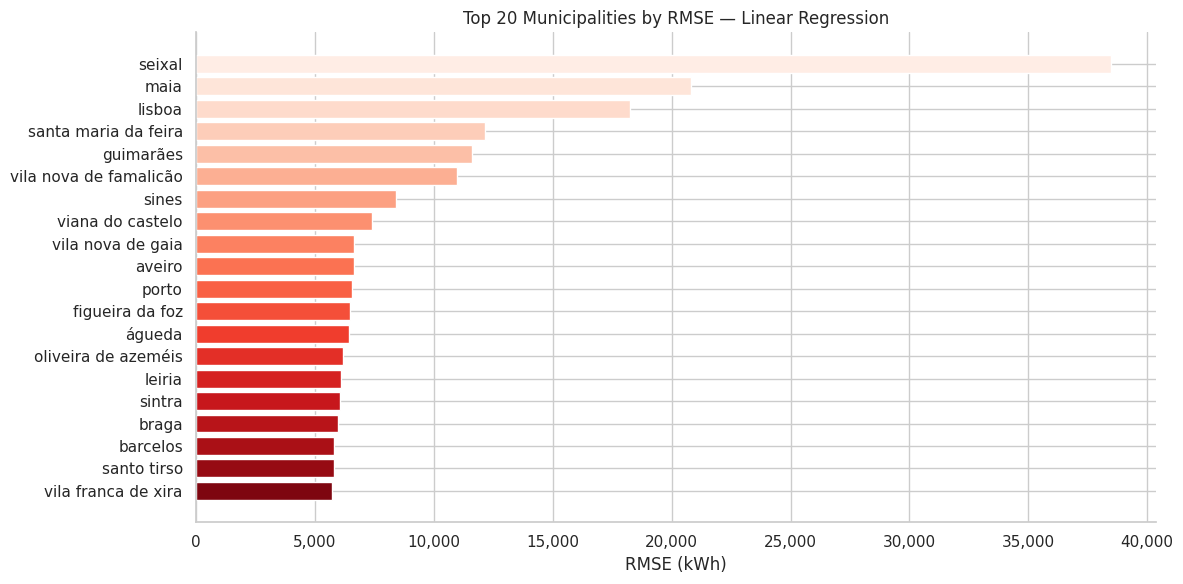

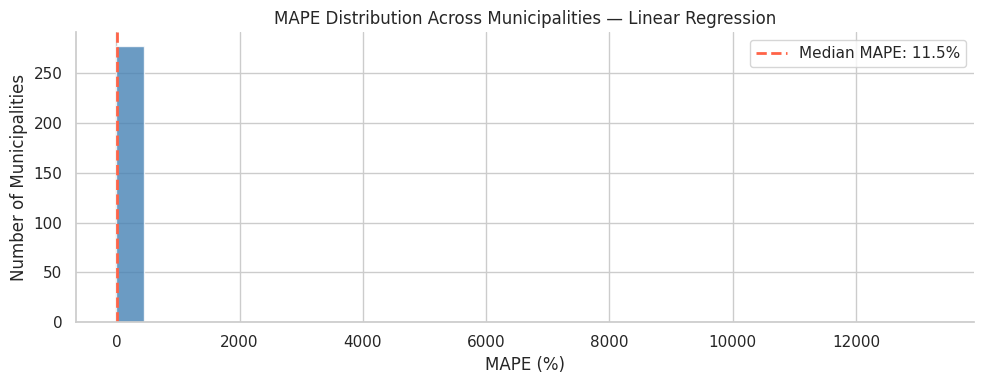

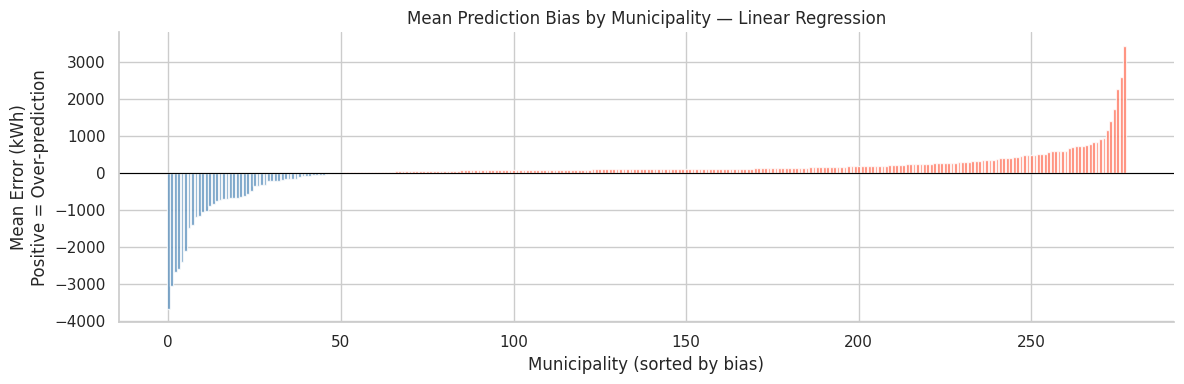

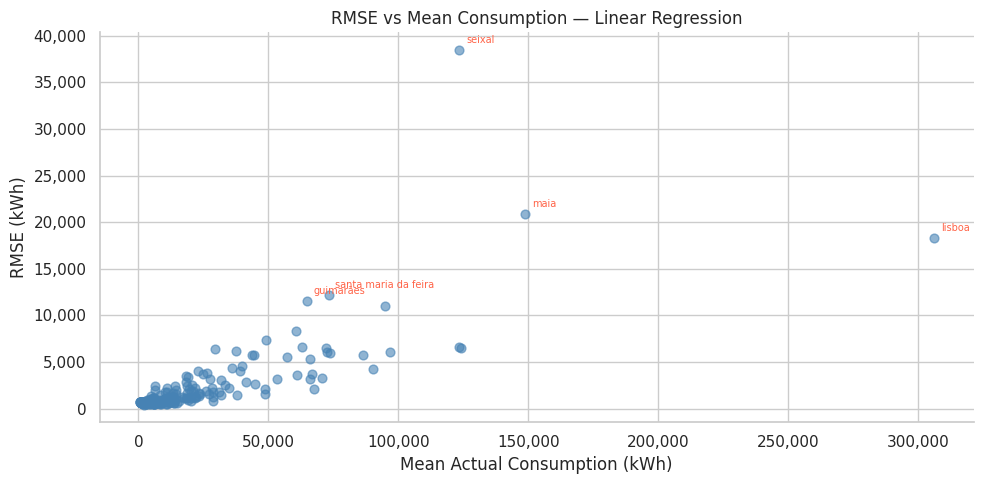

In [13]:
lr_munic  = evaluate_by_municipality(lr_test_preds,  TARGET_COL, "Linear Regression", plot=True)

In [15]:
lr_fitted_pipeline_model.stages

[StringIndexerModel: uid=StringIndexer_0831a3bbf5ea, handleInvalid=keep,
 VectorAssembler_c567cab706cc,
 StandardScalerModel: uid=StandardScaler_483607e24bc9, numFeatures=9, withMean=true, withStd=true,
 LinearRegressionModel: uid=LinearRegression_1d26da58e5fa, numFeatures=9]

In [16]:
lr_fitted_pipeline_model.write().overwrite().save(MODEL_DIR + "/" + "lr_pipeline")

---
## 6. Model 2 — Gradient Boosted Trees

GBT builds an ensemble of decision trees sequentially, each correcting the
errors of the previous. It excels at capturing non-linear relationships and
feature interactions — for example, the interaction between `hour_of_day` and
`is_holiday` (a holiday at 09:00 behaves very differently from a weekday at 09:00).

GBT is our recommended production model: fully distributed in Spark,
no feature scaling required, and provides feature importance out of the box.

In [18]:
# Run it for your Linear Regression Model
lr_cv_results = run_time_series_cv(
    df=df,
    pipeline_func=build_pipeline,
    model_estimator=lr,
    max_date_str=max_date,
    n_folds=5
)

Starting 5-Fold Time-Series Cross-Validation...
Global Data End Point: 2023-08-24 22:00:00
------------------------------------------------------------
--- FOLD 1 ---
  Training Data Ends : 2023-08-17 22:00:00
  Validation Horizon : 2023-08-17 22:00:00 to 2023-08-24 22:00:00
  Result -> RMSE: 4,206.91 | MAE: 1,411.29 | R²: 0.9797

--- FOLD 2 ---
  Training Data Ends : 2023-08-10 22:00:00
  Validation Horizon : 2023-08-10 22:00:00 to 2023-08-17 22:00:00
  Result -> RMSE: 4,267.90 | MAE: 1,567.02 | R²: 0.9760

--- FOLD 3 ---
  Training Data Ends : 2023-08-03 22:00:00
  Validation Horizon : 2023-08-03 22:00:00 to 2023-08-10 22:00:00
  Result -> RMSE: 4,627.30 | MAE: 1,381.09 | R²: 0.9761

--- FOLD 4 ---
  Training Data Ends : 2023-07-27 22:00:00
  Validation Horizon : 2023-07-27 22:00:00 to 2023-08-03 22:00:00
  Result -> RMSE: 3,503.24 | MAE: 1,315.13 | R²: 0.9860

--- FOLD 5 ---
  Training Data Ends : 2023-07-20 22:00:00
  Validation Horizon : 2023-07-20 22:00:00 to 2023-07-27 22:00:00


In [19]:
print("Training GBTRegressor...")

gbt = GBTRegressor(
    featuresCol="features",
    labelCol=TARGET_COL,
    maxIter=50,         # number of trees
    maxDepth=5,          # depth per tree — deeper = more complex, more overfit risk
    stepSize=0.1,        # learning rate
    subsamplingRate=0.8, # row subsampling — reduces overfitting
    seed=42
)

gbt_fitted_pipeline_model, gbt_train_metrics, gbt_test_metrics, gbt_test_preds = fit_and_evaluate(
    gbt, "Gradient Boosted Trees", train_df_eng, test_df_eng, TARGET_COL, cutoff_test
)

Training GBTRegressor...
Fitting Gradient Boosted Trees...

── Gradient Boosted Trees — Training ──
RMSE: 4,164.15
MAE:  1,481.38
R2:   0.9812
MAPE: 49.19%

── Gradient Boosted Trees — Test ──
RMSE: 3,897.67
MAE:  1,414.51
R2:   0.9832
MAPE: 159.82%



  Per-Municipality Evaluation — Gradient Boosted Trees
  Municipalities evaluated : 278
  Median RMSE              : 738.60 kWh
  Median MAPE              : 9.42%
  Worst municipality (RMSE): seixal  (36,456.93 kWh)
  Best  municipality (RMSE): fornos de algodres  (108.13 kWh)

          municipality  n_rows     rmse      mae  mape  mean_actual  mean_predicted  mean_bias    r2
                seixal     552 36456.93 29489.25 26.42    123444.73       112324.23  -11120.49  0.09
                  maia     552 23984.20 17598.94 12.41    148899.49       140759.33   -8140.15  0.15
                lisboa     552 17379.78 13688.74  4.62    306001.62       307176.12    1174.50  0.94
                 porto     552 13715.15 10929.77  9.39    124196.43       123211.17    -985.27  0.78
               setúbal     552 10538.54  8219.97  9.54     90205.67        97542.35    7336.68 -1.31
   vila franca de xira     552 10487.14  8603.81 10.13     86283.56        91386.30    5102.74 -0.12
vila nova de 

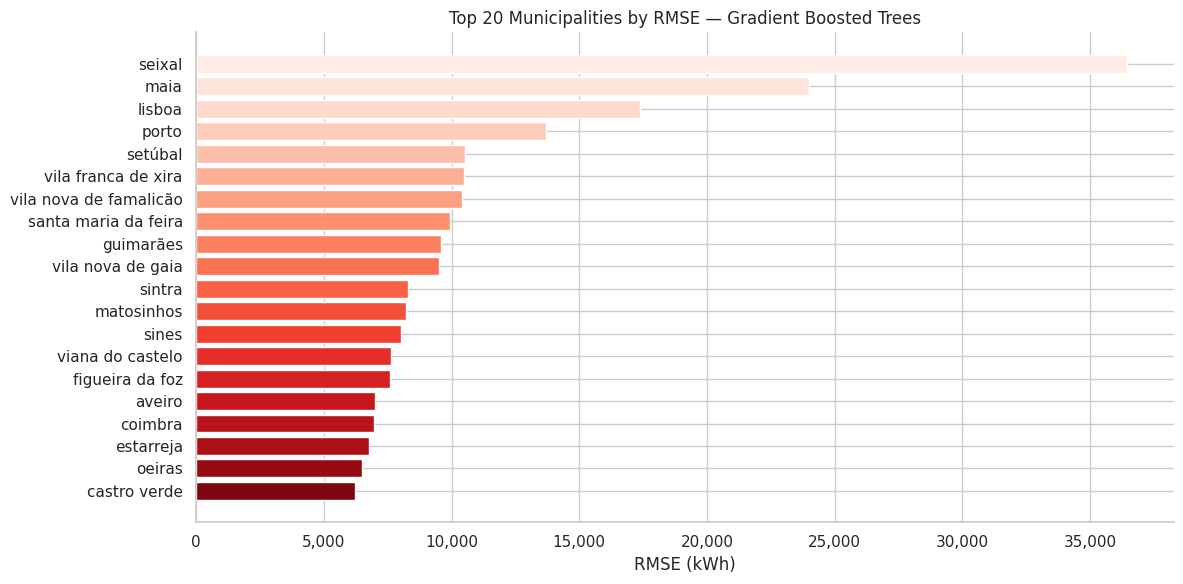

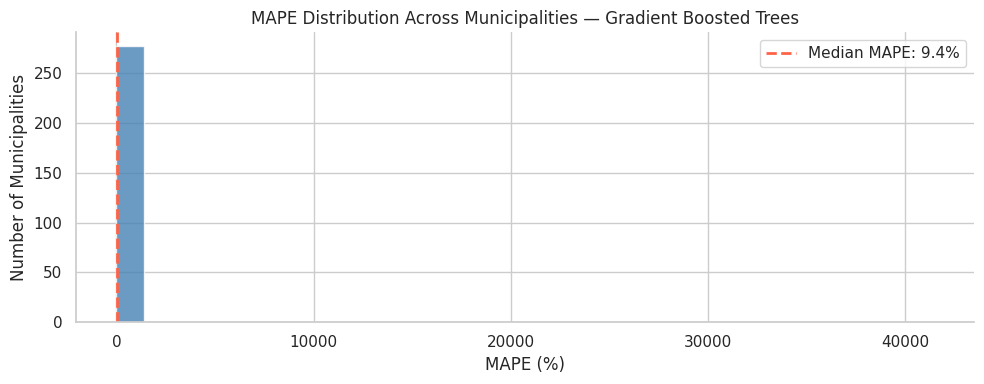

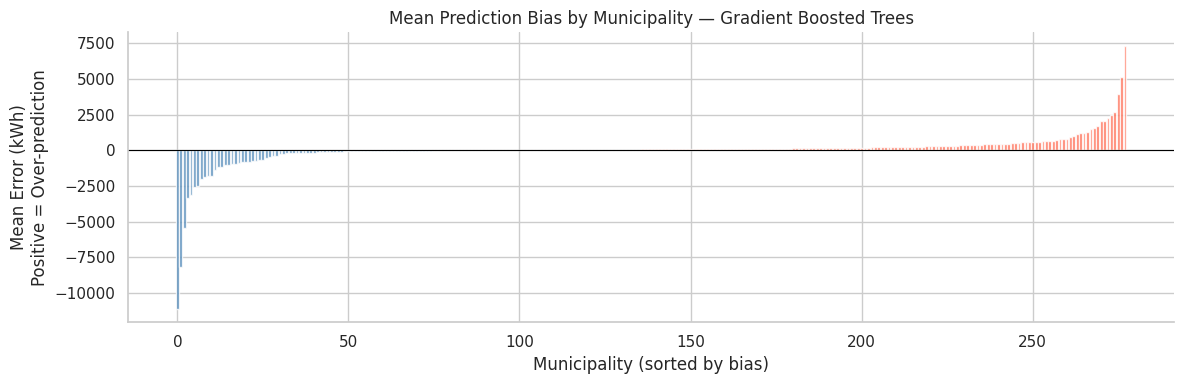

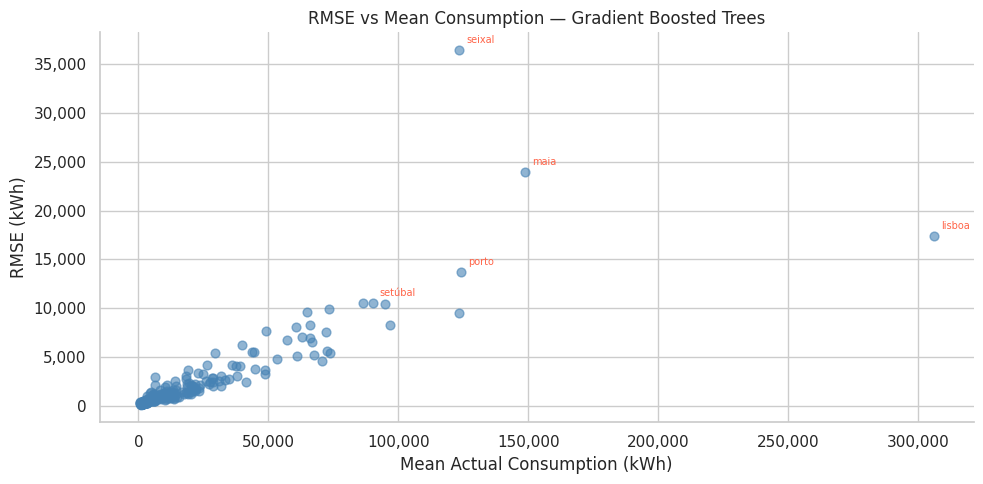

In [20]:
gbt_metrics = evaluate_by_municipality(gbt_test_preds, TARGET_COL, "Gradient Boosted Trees")

In [21]:

# Hyperparameter tuning via CrossValidator.

# We tune two key GBT hyperparameters:
#   maxDepth    — controls tree complexity (bias-variance tradeoff)
#   maxIter     — number of boosting rounds

# CrossValidator uses k-fold cross-validation. For time series, standard
# k-fold is not strictly correct (it can leak future data into earlier folds).

# For time series data, TimeSeriesSplit (walk-forward validation) is more
# appropriate as it preserves temporal order. MLlib does not natively support
# TimeSeriesSplit


# Define tuning search space parameters (small grid)
gbt_param_grid = {
    "maxDepth": [4, 6],
    "maxIter": [20, 30]
}

# Unpack the grid into individual experiment dictionaries
keys, values = zip(*gbt_param_grid.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

# Trackers for the grid leaderboard
best_rmse = float('inf')
best_params = None
all_grid_records = []


print(f"Initializing Grid Search Loop: {len(experiments)} configurations...")
print("=" * 75)

# Iterate over the parameter configurations and call function directly
for i, params in enumerate(experiments):
    print(f"\n [GRID STEP {i+1}/{len(experiments)}] Testing Configuration: {params}")
    print("=" * 75)

    # Dynamically initialize the estimator with the grid's parameter states
    gbt_estimator = GBTRegressor(
        featuresCol="features",
        labelCol=TARGET_COL,
        seed=42,
        **params
    )

    # cv function
    cv_results = run_time_series_cv(
        df=df,
        pipeline_func=build_pipeline,
        model_estimator=gbt_estimator,
        max_date_str=max_date,
        n_folds=2
    )

    # Extract the mean performance metrics
    mean_rmse = cv_results['rmse'].mean()
    mean_mae  = cv_results['mae'].mean()
    mean_r2   = cv_results['r2'].mean()

    # Save statistics for summary logging
    record = params.copy()
    record["mean_rmse"] = mean_rmse
    record["mean_mae"] = mean_mae
    record["mean_r2"] = mean_r2
    all_grid_records.append(record)

    # Check if this configuration wins the leaderboard
    if mean_rmse < best_rmse:
        best_rmse = mean_rmse
        best_params = params

# Print the final leaderboard results
print("\n" + "=" * 75)
print(" HYPERPARAMETER GRID SEARCH METRIC SUMMARY")
print("=" * 75)
print(f"Winner Configuration : {best_params}")
print(f"Top Mean CV RMSE     : {best_rmse:,.2f} kWh")
print("=" * 75)

# Convert the history log to a Pandas DataFrame for your viewing
grid_leaderboard_df = pd.DataFrame(all_grid_records).sort_values(by="mean_rmse")

Initializing Grid Search Loop: 4 configurations...

 [GRID STEP 1/4] Testing Configuration: {'maxDepth': 4, 'maxIter': 20}
Starting 2-Fold Time-Series Cross-Validation...
Global Data End Point: 2023-08-24 22:00:00
------------------------------------------------------------
--- FOLD 1 ---
  Training Data Ends : 2023-08-17 22:00:00
  Validation Horizon : 2023-08-17 22:00:00 to 2023-08-24 22:00:00
  Result -> RMSE: 5,386.60 | MAE: 2,070.95 | R²: 0.9668

--- FOLD 2 ---
  Training Data Ends : 2023-08-10 22:00:00
  Validation Horizon : 2023-08-10 22:00:00 to 2023-08-17 22:00:00
  Result -> RMSE: 5,214.35 | MAE: 2,145.17 | R²: 0.9642

FINISHED CROSS-VALIDATION SUMMARY
Mean CV RMSE : 5,300.47 kWh
Mean CV MAE  : 2,108.06 kWh
Mean CV R²   : 0.9655

 [GRID STEP 2/4] Testing Configuration: {'maxDepth': 4, 'maxIter': 30}
Starting 2-Fold Time-Series Cross-Validation...
Global Data End Point: 2023-08-24 22:00:00
------------------------------------------------------------
--- FOLD 1 ---
  Training D

In [23]:
print("Training final model with best parameters...")

best_gbt = GBTRegressor(
    featuresCol="features",
    labelCol=TARGET_COL,
    seed=42,
    **best_params
)

gbt_best_fitted_pipeline_model, gbt_best_train_metrics, gbt_best_test_metrics, gbt_best_test_preds = fit_and_evaluate(
    best_gbt, "Gradient Boosted Trees", train_df_eng, test_df_eng, TARGET_COL, cutoff_test
)

Training final model with best parameters...
Fitting Gradient Boosted Trees...

── Gradient Boosted Trees — Training ──
RMSE: 4,093.23
MAE:  1,453.35
R2:   0.9818
MAPE: 46.76%

── Gradient Boosted Trees — Test ──
RMSE: 3,857.06
MAE:  1,404.68
R2:   0.9836
MAPE: 164.67%



  Per-Municipality Evaluation — Gradient Boosted Trees
  Municipalities evaluated : 278
  Median RMSE              : 679.10 kWh
  Median MAPE              : 9.46%
  Worst municipality (RMSE): seixal  (36,606.03 kWh)
  Best  municipality (RMSE): mêda  (136.79 kWh)

          municipality  n_rows     rmse      mae  mape  mean_actual  mean_predicted  mean_bias    r2
                seixal     552 36606.03 29923.06 27.35    123444.73       113917.48   -9527.25  0.08
                  maia     552 23012.02 16833.53 11.94    148899.49       142045.21   -6854.28  0.22
                lisboa     552 17784.27 14288.02  4.84    306001.62       308608.45    2606.83  0.94
                 porto     552 13207.01 10619.26  9.10    124196.43       124869.21     672.78  0.80
               setúbal     552 10456.89  7717.99  9.07     90205.67        96878.60    6672.93 -1.27
   vila franca de xira     552  9981.13  8294.96  9.79     86283.56        91256.64    4973.07 -0.01
  santa maria da feira     

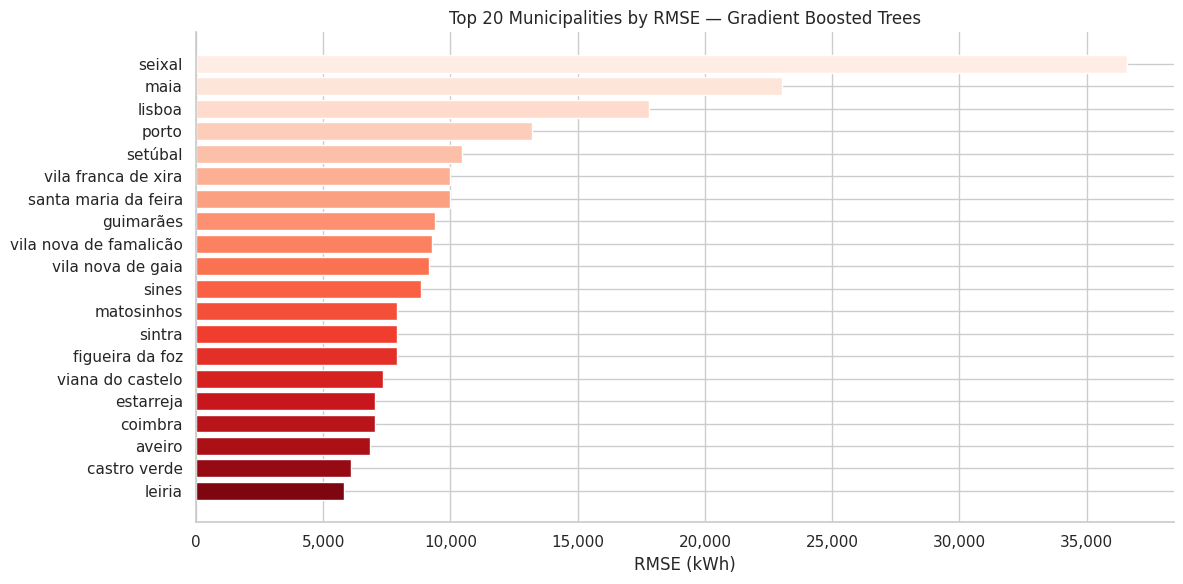

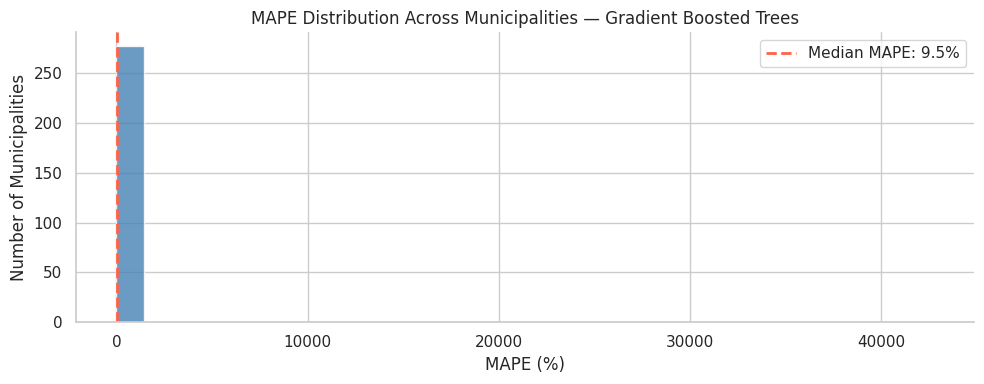

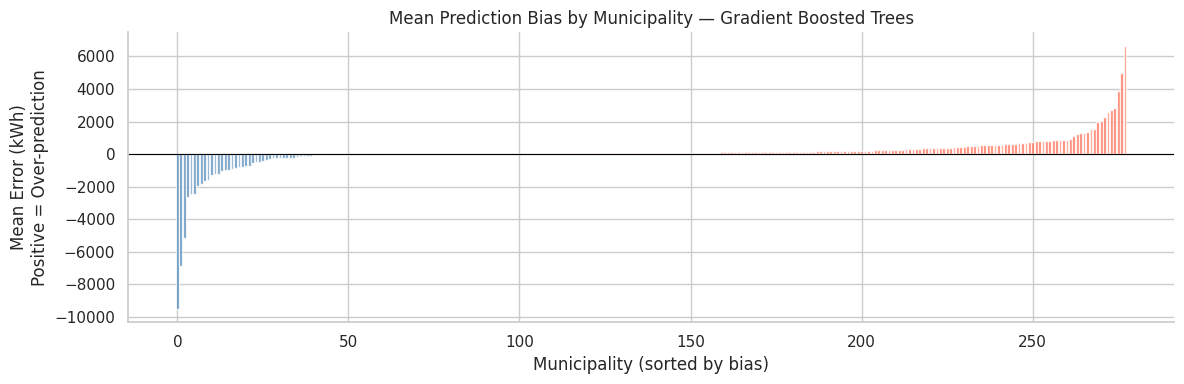

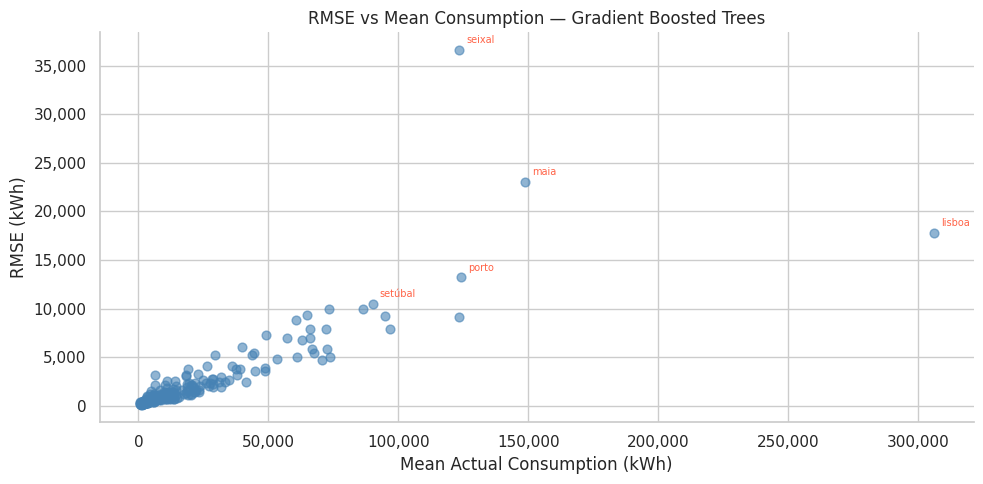

In [28]:
gbt_best_metrics = evaluate_by_municipality(gbt_best_test_preds, TARGET_COL, "Gradient Boosted Trees")

In [29]:
transformed_train = gbt_fitted_pipeline_model.transform(train_df_eng)
gbt_model = gbt_fitted_pipeline_model.stages[-1]

In [30]:
# Extract feature names from the VectorAssembler metadata.

# When OneHotEncoder is used, each categorical column expands into multiple
# binary slots in the feature vector. assembler.getInputCols() returns the
# pre-OHE column names (e.g. "hour_of_day_ohe") not the individual slot
# names (e.g. "hour_of_day_0", "hour_of_day_1", ...).

# The correct approach is to read the feature metadata from the transformed
# DataFrame schema, which Spark populates with the actual slot names after
# OHE expansion.


def extract_feature_names(pipeline_model, transformed_df, features_col="features_raw"):
    """
    Extracts the true feature names from the VectorAssembler output metadata,
    correctly handling OneHotEncoded columns which expand into multiple slots.

    Parameters
    ----------
    pipeline_model  : fitted PipelineModel
    transformed_df  : DataFrame output from pipeline_model.transform()
    features_col    : name of the assembled feature vector column

    Returns
    -------
    list of feature name strings matching the feature vector indices
    """
    feature_names = []

    # Get metadata from the schema of the assembled features column
    attrs = (
        transformed_df.schema[features_col]
        .metadata
        .get("ml_attr", {})
        .get("attrs", {})
    )

    # Nominal = OHE binary slots
    if "nominal" in attrs:
        feature_names.extend([attr["name"] for attr in attrs["nominal"]])

    # Numeric = continuous features
    if "numeric" in attrs:
        feature_names.extend([attr["name"] for attr in attrs["numeric"]])

    # Binary = binary flags (is_weekend, is_holiday)
    if "binary" in attrs:
        feature_names.extend([attr["name"] for attr in attrs["binary"]])

    # Sort by index to match the feature vector order
    all_attrs = (
        attrs.get("nominal", []) +
        attrs.get("numeric", []) +
        attrs.get("binary",  [])
    )
    all_attrs_sorted = sorted(all_attrs, key=lambda x: x["idx"])
    feature_names    = [attr["name"] for attr in all_attrs_sorted]

    return feature_names

extract_feature_names(gbt_model, transformed_train, features_col="features_raw")
# Feature Impoortance

['municipality_idx',
 'hour_of_day',
 'day_of_week',
 'day_of_month',
 'month',
 'is_weekend',
 'is_holiday',
 'lag_24h',
 'lag_168h']

In [31]:

importances = gbt_model.featureImportances.toArray()

feature_names = extract_feature_names(
    gbt_model,
    transformed_train,
    features_col="features_raw"   # or "features" depending on your pipeline
)

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi_df


,feature,importance
8,lag_168h,0.644444
7,lag_24h,0.201418
0,municipality_idx,0.083724
1,hour_of_day,0.040036
4,month,0.010494
5,is_weekend,0.006059
2,day_of_week,0.005589
3,day_of_month,0.004983
6,is_holiday,0.003252


In [32]:
gbt_fitted_pipeline_model.write().overwrite().save(MODEL_DIR + "gbt_best_pipeline")

In [33]:
spark.stop()